# Life Expectancy Prediction Pipeline Using SQL, Linear Regression, Regularization, and PCA

## 1. Project Overview

This project predicts national life expectancy using socioeconomic, mortality, health, and vaccination-related variables.

The original version of this project compared selected-feature linear regression against PCA-based regression. Version 2 extends the project into a more reproducible end-to-end data science pipeline:

1. Raw CSV data is loaded into a DuckDB database.
2. SQL views clean column names and create a modeling dataset.
3. Python modules handle preprocessing, model evaluation, regularization, PCA, and output generation.
4. Final model outputs are exported for analysis and Power BI dashboarding.

The main modeling goal is to compare:

- Linear Regression
- Ridge Regression
- Lasso Regression
- PCA + Linear Regression

The project focuses on predictive performance, cross-validation stability, interpretability, and reproducibility.

## 2. Imports and Project Setup

In [1]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.autolayout"] = True

# Project paths
PROJECT_ROOT = Path(".")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

print("Project setup complete.")

Project setup complete.


## 3. Reproducible Pipeline

The Version 2 project is structured as a reproducible pipeline instead of a notebook-only workflow.

The full pipeline can be executed from the terminal using:

```bash
python run_pipeline.py

Important: because this markdown contains a code fence inside it, Jupyter may be weird if you copy the full thing. If it causes formatting issues, remove the triple backticks and just write:

```text
python run_pipeline.py

In [2]:
# Optional: run the full pipeline from inside the notebook.
# This regenerates the database, dashboard outputs, model comparison, and predictions

from run_pipeline import run_pipeline

# Uncomment the line below if you want to rerun the entire project pipeline
# run_pipeline()

## 4. Load Processed Project Outputs

After running the pipeline, the project creates processed CSV files in `data/processed/`.

These files are used for analysis, model comparison, prediction review, and Power BI dashboarding.

In [3]:
# Load processed outputs created by the pipeline

overview_summary = pd.read_csv(PROCESSED_DIR / "overview_summary.csv")
status_summary = pd.read_csv(PROCESSED_DIR / "status_summary.csv")
year_summary = pd.read_csv(PROCESSED_DIR / "year_summary.csv")
country_summary = pd.read_csv(PROCESSED_DIR / "country_summary.csv")
missingness_summary = pd.read_csv(PROCESSED_DIR / "missingness_summary.csv")

ridge_alpha_tuning = pd.read_csv(PROCESSED_DIR / "ridge_alpha_tuning.csv")
lasso_alpha_tuning = pd.read_csv(PROCESSED_DIR / "lasso_alpha_tuning.csv")
model_comparison = pd.read_csv(PROCESSED_DIR / "model_comparison.csv")
predictions = pd.read_csv(PROCESSED_DIR / "predictions.csv")
linear_regression_coefficients = pd.read_csv(PROCESSED_DIR / "linear_regression_coefficients.csv")
print("Processed outputs loaded successfully.")

Processed outputs loaded successfully.


In [4]:
# Verify the main processed outputs

processed_files = [
    "overview_summary.csv",
    "status_summary.csv",
    "year_summary.csv",
    "country_summary.csv",
    "missingness_summary.csv",
    "ridge_alpha_tuning.csv",
    "lasso_alpha_tuning.csv",
    "model_comparison.csv",
    "predictions.csv"
]

for file_name in processed_files:
    file_path = PROCESSED_DIR / file_name
    print(f"{file_name}: {file_path.exists()}")

overview_summary.csv: True
status_summary.csv: True
year_summary.csv: True
country_summary.csv: True
missingness_summary.csv: True
ridge_alpha_tuning.csv: True
lasso_alpha_tuning.csv: True
model_comparison.csv: True
predictions.csv: True


## 5. Dataset Overview

This section summarizes the SQL-generated dataset used for analysis and modeling.

The original dataset contains country-level life expectancy observations across multiple years, with predictors related to mortality, immunization, healthcare spending, economic development, education, and population health.

In [5]:
# Display the high-level dataset overview created from SQL

overview_summary

,total_rows,unique_countries,first_year,last_year,unique_status_values,avg_life_expectancy
0,2928,183,2000,2015,2,69.22


### Development Status Summary

The dataset separates countries into development status categories. This summary compares the average, minimum, maximum, and standard deviation of life expectancy by status.

In [6]:
# Display life expectancy summary by country development status

status_summary

,status,num_records,avg_life_expectancy,min_life_expectancy,max_life_expectancy,std_life_expectancy
0,Developed,528,79.29,69.9,89.0,3.94
1,Developing,2400,67.01,36.3,89.0,8.95


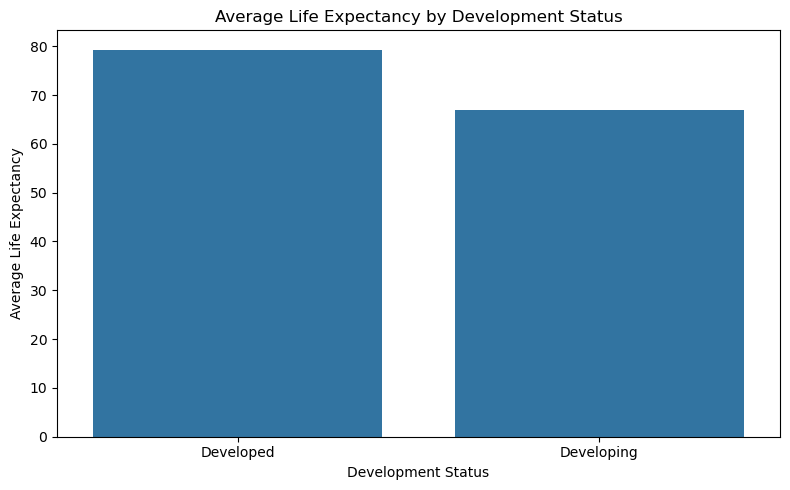

In [7]:
# Plot average life expectancy by development status

plt.figure(figsize=(8, 5))

sns.barplot(
    data=status_summary,
    x="status",
    y="avg_life_expectancy"
)

plt.title("Average Life Expectancy by Development Status")
plt.xlabel("Development Status")
plt.ylabel("Average Life Expectancy")
plt.show()

### Life Expectancy Over Time

This summary shows how average life expectancy changes across years in the dataset.

In [8]:
# Display average life expectancy by year

year_summary.head()

,year,num_records,avg_life_expectancy,min_life_expectancy,max_life_expectancy
0,2000,183,66.75,39.0,81.1
1,2001,183,67.13,41.0,82.0
2,2002,183,67.35,44.0,84.0
3,2003,183,67.43,41.5,87.0
4,2004,183,67.65,42.3,89.0


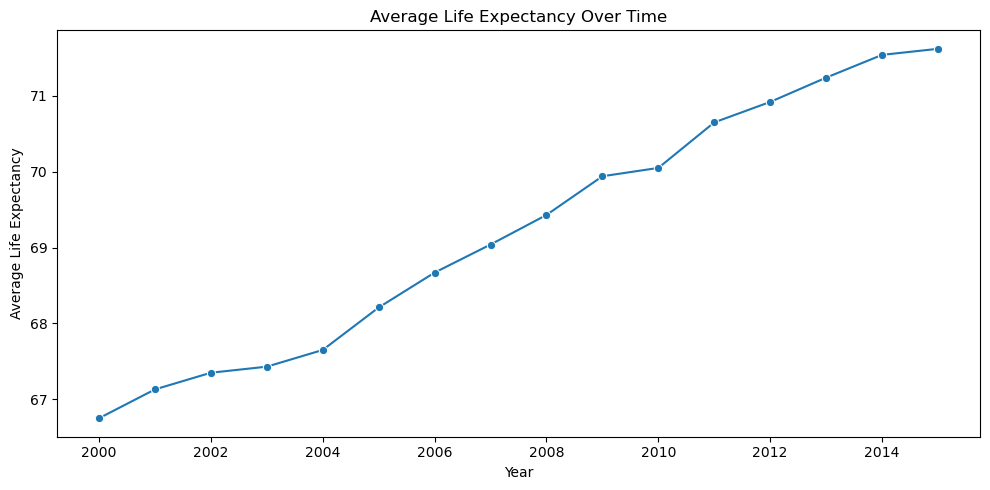

In [9]:
# Plot average life expectancy over time

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=year_summary,
    x="year",
    y="avg_life_expectancy",
    marker="o"
)

plt.title("Average Life Expectancy Over Time")
plt.xlabel("Year")
plt.ylabel("Average Life Expectancy")
plt.show()

### Country-Level Summary

The country-level summary aggregates life expectancy and selected predictor averages by country and development status.

In [10]:
# Display the country-level summary

country_summary.head(10)

,country,status,num_records,first_year,last_year,avg_life_expectancy,min_life_expectancy,max_life_expectancy,avg_gdp,avg_schooling,avg_adult_mortality
0,Japan,Developed,16,2000,2015,82.54,81.1,83.7,37226.53,14.98,64.29
1,Sweden,Developed,16,2000,2015,82.52,79.6,89.0,43728.39,15.87,62.67
2,Iceland,Developed,16,2000,2015,82.44,79.7,88.0,45796.96,18.16,59.46
3,Switzerland,Developed,16,2000,2015,82.33,79.7,85.0,64572.83,15.39,62.86
4,France,Developed,16,2000,2015,82.22,78.8,89.0,34444.95,15.90,87.15
5,Italy,Developed,16,2000,2015,82.19,79.4,89.0,33178.81,15.93,65.31
6,Spain,Developed,16,2000,2015,82.07,79.1,89.0,25889.01,16.36,71.79
7,Australia,Developed,16,2000,2015,81.81,79.5,86.0,49078.93,20.04,67.00
8,Norway,Developed,16,2000,2015,81.79,78.5,89.0,65060.30,17.47,70.20
9,Canada,Developing,16,2000,2015,81.69,79.1,87.0,37928.31,15.88,72.79


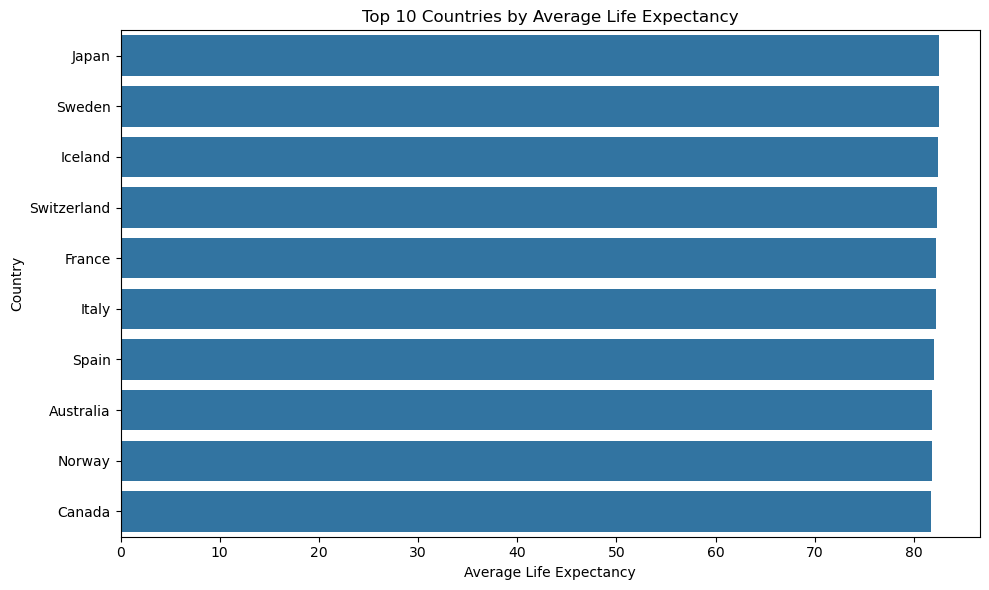

In [11]:
# Plot the top 10 countries by average life expectancy

top_10_life_expectancy = country_summary.sort_values(
    "avg_life_expectancy",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_life_expectancy,
    x="avg_life_expectancy",
    y="country"
)

plt.title("Top 10 Countries by Average Life Expectancy")
plt.xlabel("Average Life Expectancy")
plt.ylabel("Country")
plt.show()

### Missingness Summary

Missing values are important because several predictors contain incomplete country-year observations. The modeling pipeline handles missing numerical predictors using KNN imputation after train/test splitting to avoid data leakage.

In [12]:
# Display missingness summary sorted by missing percentage

missingness_summary.sort_values("missing_percent", ascending=False)

,column_name,missing_count,missing_percent
0,population,1850.0,63.18
1,gdp,1284.0,43.85
2,percentage_expenditure,1174.0,40.10
3,hepatitis_b,553.0,18.89
4,adult_mortality,521.0,17.79
5,bmi,312.0,10.66
6,income_composition_of_resources,290.0,9.90
7,total_expenditure,226.0,7.72
8,alcohol,193.0,6.59
9,schooling,160.0,5.46


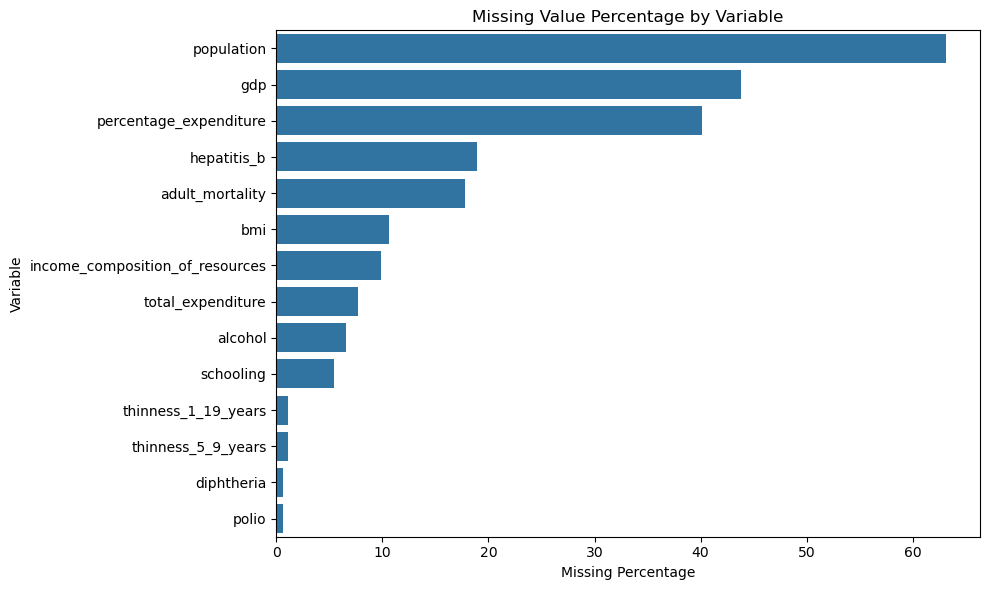

In [13]:
# Plot missing percentage by variable

missingness_sorted = missingness_summary.sort_values(
    "missing_percent",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=missingness_sorted,
    x="missing_percent",
    y="column_name"
)

plt.title("Missing Value Percentage by Variable")
plt.xlabel("Missing Percentage")
plt.ylabel("Variable")
plt.show()

### Dataset Overview Takeaways

The dataset contains a broad set of country-year observations covering both developed and developing countries. Average life expectancy differs strongly by development status, and the yearly summary shows the overall time trend in the dataset.

Several economic and health-related predictors contain missing values, especially variables such as GDP, population, and hepatitis B vaccination rates. Because of this, the modeling workflow uses a structured preprocessing pipeline with zero-to-missing replacement, log transformations, KNN imputation, and scaling.

## 6. Model Comparison

The modeling workflow compares four regression approaches:

1. Linear Regression with six selected predictors
2. Ridge Regression with tuned L2 regularization
3. Lasso Regression with tuned L1 regularization
4. PCA + Linear Regression using dimensionality reduction

Ridge and Lasso regularization strengths were selected using repeated K-fold cross-validation on the training set only. The final test set was kept separate for final model evaluation.

### Ridge Alpha Tuning

Ridge Regression uses L2 regularization. The alpha parameter controls the strength of coefficient shrinkage. Larger alpha values apply stronger regularization.

In [14]:
# Display Ridge alpha tuning results

ridge_alpha_tuning

,model,alpha,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,ridge,0.001,2.824096,0.105150,0.911717,0.008440
1,ridge,0.010,2.824097,0.105151,0.911717,0.008440
2,ridge,0.100,2.824100,0.105159,0.911716,0.008439
3,ridge,1.000,2.824166,0.105241,0.911713,0.008429
4,ridge,10.000,2.826972,0.106149,0.911543,0.008357
5,ridge,100.000,2.884244,0.113532,0.907952,0.008345


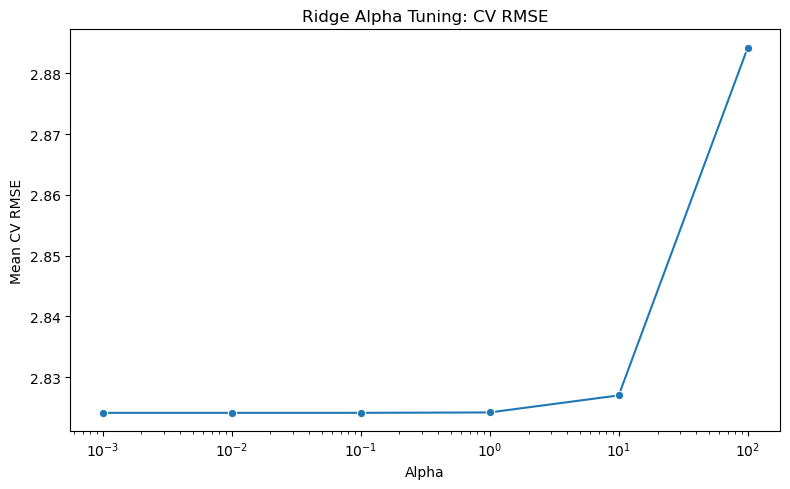

In [15]:
# Plot Ridge alpha tuning results

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=ridge_alpha_tuning,
    x="alpha",
    y="cv_rmse_mean",
    marker="o"
)

plt.xscale("log")
plt.title("Ridge Alpha Tuning: CV RMSE")
plt.xlabel("Alpha")
plt.ylabel("Mean CV RMSE")
plt.show()

### Lasso Alpha Tuning

Lasso Regression uses L1 regularization. Unlike Ridge, Lasso can shrink some coefficients exactly to zero, which can act like feature selection.

In [16]:
# Display Lasso alpha tuning results

lasso_alpha_tuning

,model,alpha,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,lasso,0.0001,2.824103,0.105156,0.911716,0.008440
1,lasso,0.0010,2.824176,0.105207,0.911712,0.008433
2,lasso,0.0100,2.825310,0.105715,0.911645,0.008384
3,lasso,0.0500,2.829251,0.104365,0.911403,0.008274
4,lasso,0.1000,2.832558,0.102729,0.911212,0.008075
5,lasso,0.5000,2.890901,0.107151,0.907580,0.007822
6,lasso,1.0000,3.055126,0.115827,0.896869,0.007817


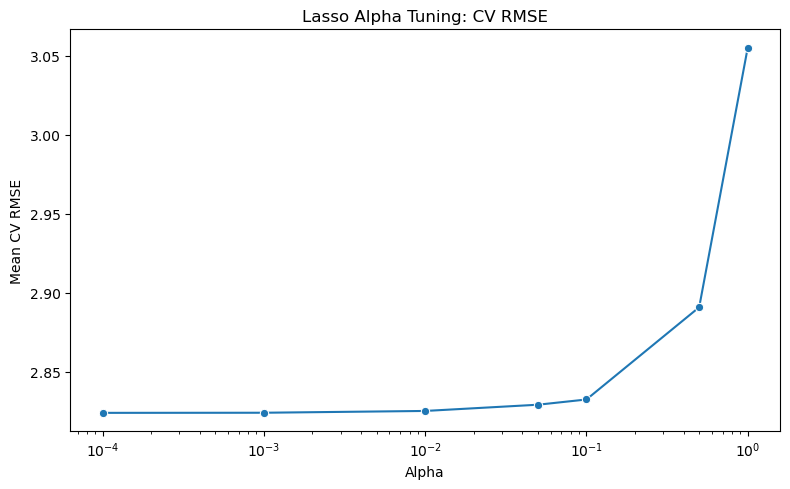

In [17]:
# Plot Lasso alpha tuning results
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=lasso_alpha_tuning,
    x="alpha",
    y="cv_rmse_mean",
    marker="o"
)

plt.xscale("log")
plt.title("Lasso Alpha Tuning: CV RMSE")
plt.xlabel("Alpha")
plt.ylabel("Mean CV RMSE")
plt.show()

### Final Model Comparison

The final model comparison uses repeated K-fold cross-validation on the training data and a separate holdout test set for final evaluation.

RMSE measures prediction error in life expectancy years, so lower is better. R² measures the proportion of variance explained, so higher is better.

In [18]:
# Display the final model comparison table

model_comparison

,model,setup,model_type,alpha,use_pca,n_components,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,test_rmse,test_r2,train_rmse,train_r2
0,Linear Regression,6 selected features,linear,1.0000,False,NaN,2.8241,0.1051,0.9117,0.0084,2.8642,0.9089,2.8062,0.9134
1,Ridge Regression,"6 selected features, tuned alpha=0.001",ridge,0.0010,False,NaN,2.8241,0.1052,0.9117,0.0084,2.8642,0.9089,2.8062,0.9134
2,Lasso Regression,"6 selected features, tuned alpha=0.0001",lasso,0.0001,False,NaN,2.8241,0.1052,0.9117,0.0084,2.8641,0.9089,2.8062,0.9134
3,PCA + Linear Regression,10 selected features reduced to 3 PCA components,linear,1.0000,True,3.0,3.1219,0.1174,0.8921,0.0104,3.0769,0.8949,3.0971,0.8945


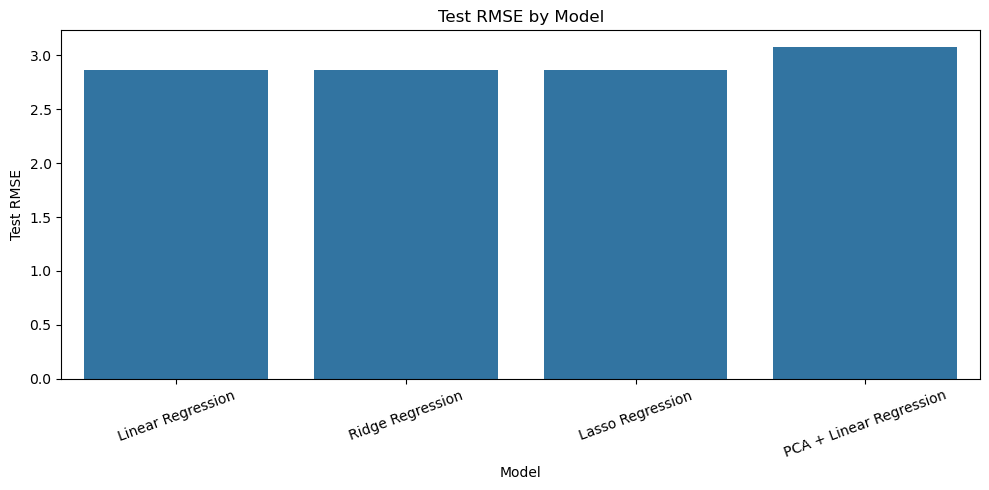

In [19]:
# Plot test RMSE by model

plt.figure(figsize=(10, 5))

sns.barplot(
    data=model_comparison,
    x="model",
    y="test_rmse"
)

plt.title("Test RMSE by Model")
plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.xticks(rotation=20)
plt.show()

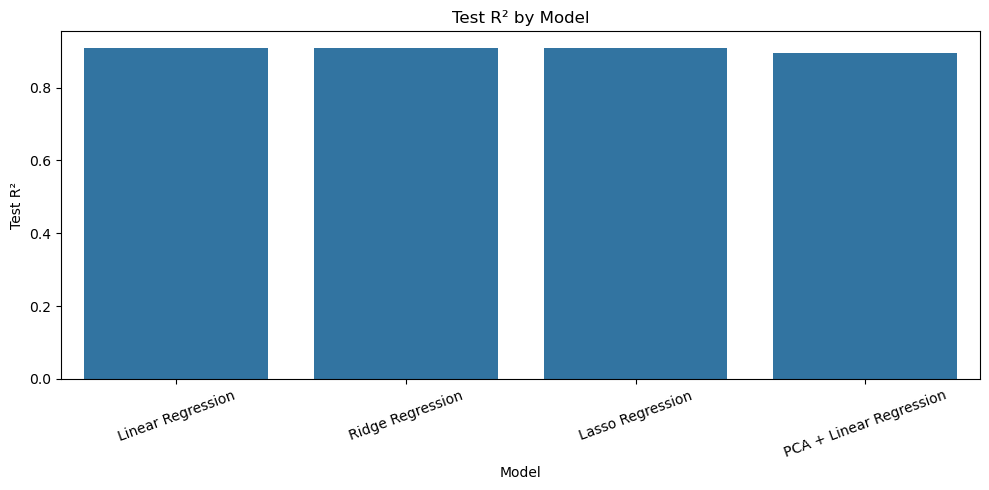

In [20]:
# Plot test R-squared by model

plt.figure(figsize=(10, 5))

sns.barplot(
    data=model_comparison,
    x="model",
    y="test_r2"
)

plt.title("Test R² by Model")
plt.xlabel("Model")
plt.ylabel("Test R²")
plt.xticks(rotation=20)
plt.show()

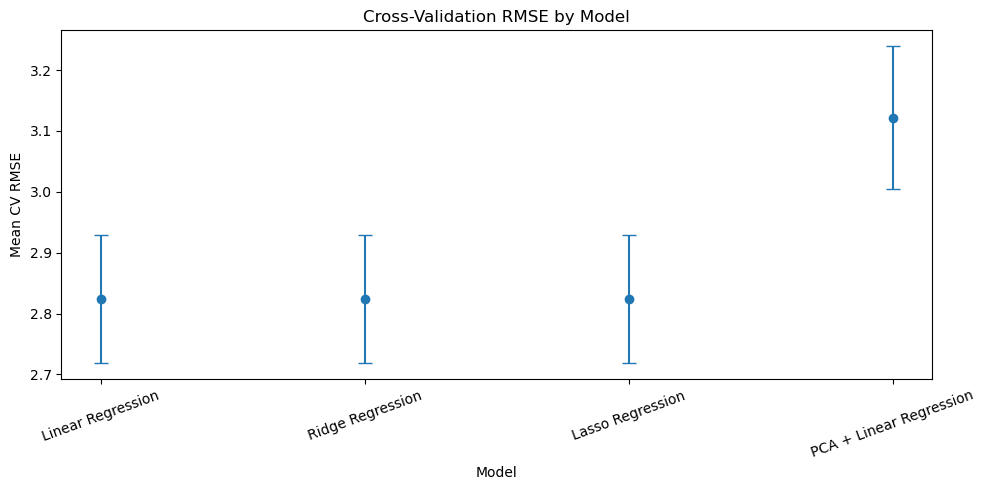

In [21]:
# Plot cross-validation RMSE mean with standard deviation

plt.figure(figsize=(10, 5))

plt.errorbar(
    x=model_comparison["model"],
    y=model_comparison["cv_rmse_mean"],
    yerr=model_comparison["cv_rmse_std"],
    fmt="o",
    capsize=5
)

plt.title("Cross-Validation RMSE by Model")
plt.xlabel("Model")
plt.ylabel("Mean CV RMSE")
plt.xticks(rotation=20)
plt.show()

### Model Comparison Takeaways

Linear Regression, Ridge Regression, and Lasso Regression performed almost identically on the holdout test set. This suggests that the selected six predictors already capture most of the useful linear signal in the dataset, and additional regularization does not meaningfully improve predictive accuracy.

Ridge Regression selected a very small alpha value, meaning the model behaved very similarly to standard Linear Regression. Lasso Regression also performed similarly, though its regularization can still be useful when feature selection or coefficient sparsity is a priority.

PCA + Linear Regression produced slightly weaker test performance, but it had lower cross-validation RMSE variability. This suggests that PCA may provide a more stable lower-dimensional representation, even though it sacrifices some interpretability and raw predictive accuracy.

Overall, the final preferred predictive model is Linear Regression with six selected predictors because it is accurate, simple, and easy to interpret. PCA + Linear Regression remains a useful dimensionality-reduction alternative.

## 7. Prediction and Residual Analysis

After selecting Linear Regression as the preferred final predictive model, the pipeline exports test-set predictions for error analysis.

The predictions table includes:

- Country
- Year
- Development status
- Actual life expectancy
- Predicted life expectancy
- Residual error
- Absolute error

Residual analysis helps evaluate where the model performs well and where prediction errors are larger.

In [22]:
# Display the first few prediction results

predictions.head()

,country,year,status,actual_life_expectancy,predicted_life_expectancy,residual,absolute_error
0,South Africa,2009,Developing,56.5,55.42,1.08,1.08
1,Bangladesh,2011,Developing,73.0,68.49,4.51,4.51
2,Singapore,2012,Developed,82.5,83.63,-1.13,1.13
3,Montenegro,2012,Developing,75.6,75.16,0.44,0.44
4,Guinea-Bissau,2003,Developing,53.0,54.83,-1.83,1.83


In [23]:
# Summary statistics for prediction errors

prediction_error_summary = predictions[
    ["residual", "absolute_error"]
].describe()

prediction_error_summary

,residual,absolute_error
count,1025.000000,1025.000000
mean,0.073210,2.045307
std,2.864721,2.006147
min,-16.900000,0.000000
25%,-1.360000,0.760000
50%,0.020000,1.410000
75%,1.440000,2.630000
max,10.680000,16.900000


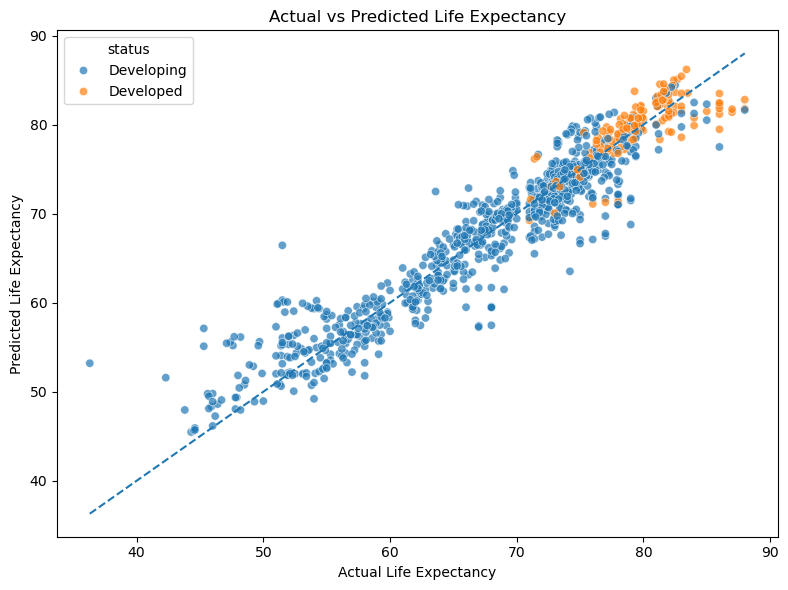

In [24]:
# Plot actual vs predicted life expectancy

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=predictions,
    x="actual_life_expectancy",
    y="predicted_life_expectancy",
    hue="status",
    alpha=0.7
)

# Add a reference line where predicted = actual
min_value = min(
    predictions["actual_life_expectancy"].min(),
    predictions["predicted_life_expectancy"].min()
)

max_value = max(
    predictions["actual_life_expectancy"].max(),
    predictions["predicted_life_expectancy"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Life Expectancy")
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.show()

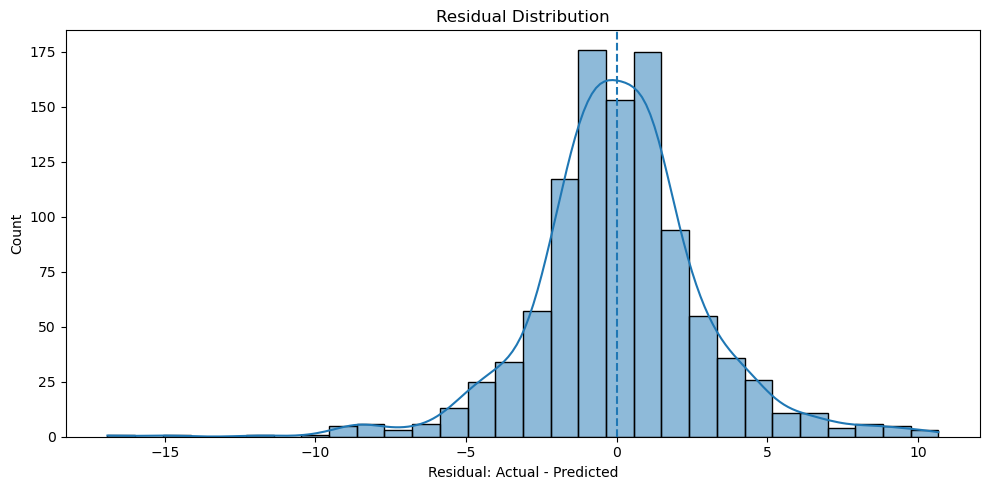

In [25]:
# Plot residual distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=predictions,
    x="residual",
    bins=30,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Residual Distribution")
plt.xlabel("Residual: Actual - Predicted")
plt.ylabel("Count")
plt.show()

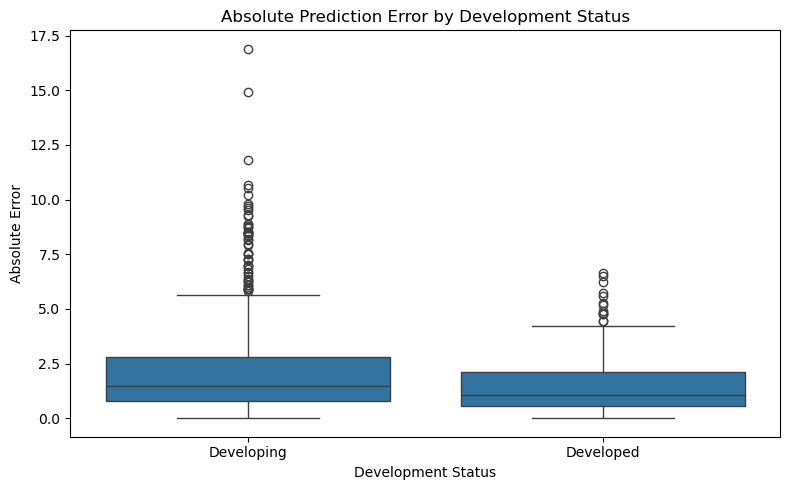

In [26]:
# Plot absolute error by development status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=predictions,
    x="status",
    y="absolute_error"
)

plt.title("Absolute Prediction Error by Development Status")
plt.xlabel("Development Status")
plt.ylabel("Absolute Error")
plt.show()

In [27]:
# Show countries with the largest absolute prediction errors

largest_errors = predictions.sort_values(
    "absolute_error",
    ascending=False
).head(10)

largest_errors

,country,year,status,actual_life_expectancy,predicted_life_expectancy,residual,absolute_error
809,Haiti,2010,Developing,36.3,53.20,-16.90,16.90
747,Somalia,2007,Developing,51.5,66.44,-14.94,14.94
207,Angola,2000,Developing,45.3,57.11,-11.81,11.81
757,Antigua and Barbuda,2003,Developing,74.2,63.52,10.68,10.68
941,Rwanda,2008,Developing,68.0,57.46,10.54,10.54
350,Saint Vincent and the Grenadines,2001,Developing,79.0,68.77,10.23,10.23
677,Sierra Leone,2007,Developing,45.3,55.11,-9.81,9.81
526,Uganda,2013,Developing,67.0,57.27,9.73,9.73
339,Zimbabwe,2015,Developing,67.0,57.39,9.61,9.61
290,Guatemala,2010,Developing,77.0,67.48,9.52,9.52


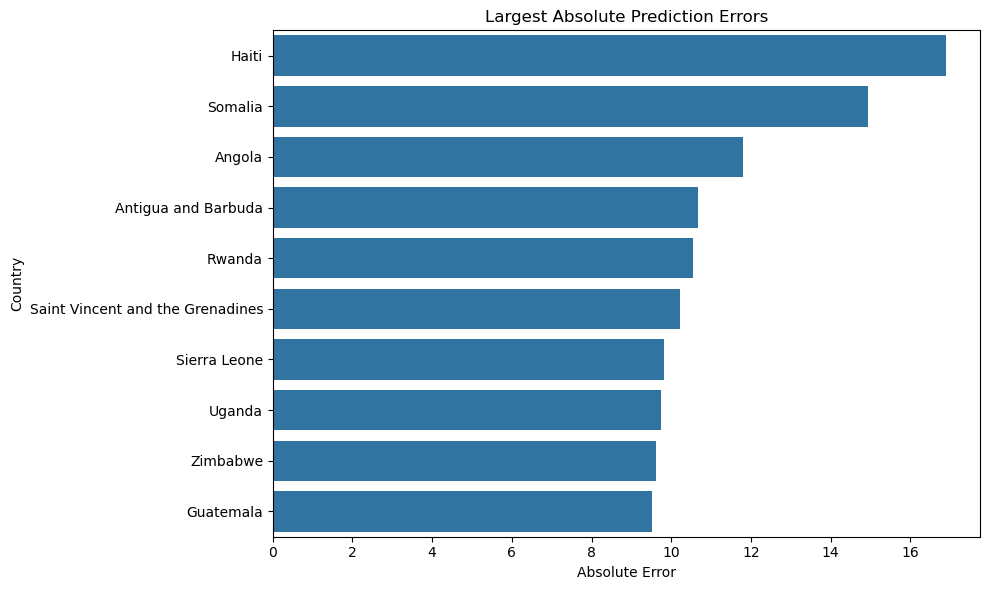

In [28]:
# Plot the 10 largest absolute prediction errors

plt.figure(figsize=(10, 6))

sns.barplot(
    data=largest_errors,
    x="absolute_error",
    y="country"
)

plt.title("Largest Absolute Prediction Errors")
plt.xlabel("Absolute Error")
plt.ylabel("Country")
plt.show()

### Prediction and Residual Analysis Takeaways

The actual-versus-predicted plot shows that most predictions fall close to the reference line, which supports the strong test-set R² score. The residual distribution is centered near zero, suggesting that the final Linear Regression model does not show a major overall bias toward overprediction or underprediction.

The largest prediction errors are still important because they identify country-year observations where the selected predictors do not fully explain life expectancy. These larger errors may reflect unusual historical, economic, political, healthcare, or data-quality conditions that are not completely captured by the six selected predictors.

The residual analysis also supports why the project includes both predictive modeling and dashboard-ready outputs. Prediction error can be explored by country, year, and development status in Power BI.

## 8. Feature and Model Interpretation

Linear Regression was selected as the preferred final predictive model because it achieved strong predictive performance while remaining simple and interpretable.

Unlike PCA regression, which transforms predictors into principal components, the selected-feature Linear Regression model keeps the original predictor names. This makes it easier to explain how each variable relates to predicted life expectancy.

The final selected predictors are:

- Adult mortality
- Income composition of resources
- Schooling
- BMI
- GDP
- HIV/AIDS

The model also includes development status after categorical encoding.

In [29]:
# Import tools needed to recreate the final Linear Regression model

import duckdb

from sklearn.model_selection import train_test_split

from src.modeling import train_regression_model
from src.preprocessing import preprocess_features

In [30]:
# Load the SQL-generated modeling dataset from DuckDB

database_path = PROJECT_ROOT / "data" / "database" / "life_expectancy.duckdb"

conn = duckdb.connect(database_path)

modeling_df = conn.execute("""
SELECT *
FROM modeling_life_expectancy;
""").fetchdf()

conn.close()

modeling_df.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness_1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,NaN,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,NaN,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,NaN,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,NaN,NaN,18.2,18.2,0.454,9.5


In [31]:
# Recreate the same train/test split used in the pipeline

X = modeling_df.drop(columns=["life_expectancy"]).copy()
y = modeling_df["life_expectancy"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.35,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1903, 21)
X_test shape: (1025, 21)


In [32]:
# Define the final selected features and preprocessing choices

optimized_features_6 = [
    "adult_mortality",
    "income_composition_of_resources",
    "schooling",
    "bmi",
    "gdp",
    "hiv_aids"
]

zero_to_nan_features = [
    "gdp",
    "percentage_expenditure"
]

log_features = [
    "adult_mortality",
    "gdp",
    "hiv_aids",
    "percentage_expenditure"
]

In [33]:
# Train the final Linear Regression model

final_linear_result = train_regression_model(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    selected_features=optimized_features_6,
    log_features=log_features,
    zero_to_nan_features=zero_to_nan_features,
    model_type="linear",
    alpha=1.0,
    scale=True,
    use_pca=False
)

final_linear_result

{'model': LinearRegression(),
 'preprocessing_objects': {'imputer': KNNImputer(weights='distance'),
  'scaler': StandardScaler(),
  'pca_model': None},
 'model_type': 'linear',
 'alpha': 1.0,
 'use_pca': False,
 'n_components': None,
 'selected_features': ['adult_mortality',
  'income_composition_of_resources',
  'schooling',
  'bmi',
  'gdp',
  'hiv_aids'],
 'train_rmse': np.float64(2.806218076931417),
 'test_rmse': np.float64(2.8641685955165093),
 'train_r2': 0.9134256606022085,
 'test_r2': 0.9089349942250843}

In [34]:
# Recreate the processed training data so we can get the final feature names

X_train_prep, X_test_prep, prep_objects = preprocess_features(
    X_train=X_train,
    X_test=X_test,
    selected_features=optimized_features_6,
    log_features=log_features,
    zero_to_nan_features=zero_to_nan_features,
    scale=True,
    use_pca=False
)

X_train_prep.head()

,adult_mortality,income_composition_of_resources,schooling,bmi,gdp,hiv_aids,status_Developing
2329,-0.332531,0.834689,0.665422,0.702866,0.763327,-0.537387,-2.063227
1071,0.517987,-0.684772,-1.129985,0.143918,-0.547331,-0.421619,0.484678
2147,0.659608,-1.067628,-0.453028,-1.242983,-1.154349,0.041800,0.484678
2001,-0.510902,0.487725,0.400526,0.771142,0.383502,-0.537387,0.484678
118,-1.658219,1.624330,2.078201,1.254759,1.667815,-0.537387,-2.063227


In [35]:
# Create a coefficient table for the final Linear Regression model

final_model = final_linear_result["model"]

coefficient_table = pd.DataFrame({
    "feature": X_train_prep.columns,
    "coefficient": final_model.coef_
})

# Add absolute coefficient size for sorting
coefficient_table["absolute_coefficient"] = coefficient_table["coefficient"].abs()

# Sort by coefficient magnitude
coefficient_table = coefficient_table.sort_values(
    "absolute_coefficient",
    ascending=False
)

coefficient_table

,feature,coefficient,absolute_coefficient
1,income_composition_of_resources,4.634342,4.634342
0,adult_mortality,-4.318589,4.318589
5,hiv_aids,-1.563774,1.563774
2,schooling,-0.541274,0.541274
4,gdp,-0.422726,0.422726
3,bmi,0.396497,0.396497
6,status_Developing,0.175863,0.175863


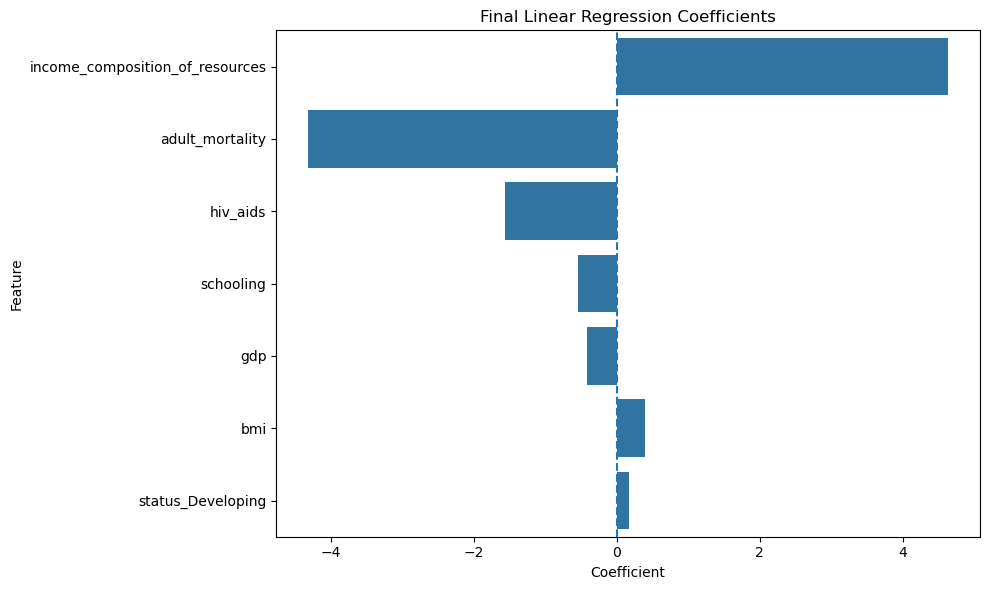

In [36]:
# Plot final model coefficients

plt.figure(figsize=(10, 6))

sns.barplot(
    data=coefficient_table,
    x="coefficient",
    y="feature"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Final Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

In [37]:
# Save coefficient table for documentation and possible Power BI use

coefficient_table.to_csv(
    PROCESSED_DIR / "linear_regression_coefficients.csv",
    index=False
)

print("Saved coefficient table to data/processed/linear_regression_coefficients.csv")

Saved coefficient table to data/processed/linear_regression_coefficients.csv


### Feature Interpretation Takeaways

The coefficient table shows the direction and relative strength of each predictor after preprocessing, imputation, and scaling. Because the numerical predictors are standardized before modeling, the coefficient magnitudes are more comparable than they would be on the original raw scales.

Positive coefficients indicate predictors associated with higher predicted life expectancy, while negative coefficients indicate predictors associated with lower predicted life expectancy.

The strongest relationships are expected to come from variables connected to mortality, education, economic development, and disease burden. Adult mortality and HIV/AIDS are typically associated with lower predicted life expectancy, while schooling and income composition of resources are typically associated with higher predicted life expectancy.

These coefficients should be interpreted as model associations rather than causal effects. The dataset is observational, and many predictors are correlated with broader social, economic, and healthcare conditions.

## 9. Power BI Dashboard Outputs

The pipeline exports multiple processed CSV files that can be used directly in Power BI.

These files support dashboard visuals for:

- Dataset overview
- Life expectancy trends over time
- Life expectancy by development status
- Country-level comparisons
- Missing data review
- Model comparison
- Prediction error analysis
- Linear Regression coefficient interpretation

The Power BI layer is intended to make the model results easier to explore interactively by country, year, and development status.

In [38]:
# List processed files available for dashboarding and documentation

processed_output_files = sorted([
    file.name
    for file in PROCESSED_DIR.iterdir()
    if file.suffix == ".csv"
])

processed_output_files

['country_summary.csv',
 'lasso_alpha_tuning.csv',
 'linear_regression_coefficients.csv',
 'missingness_summary.csv',
 'model_comparison.csv',
 'modeling_life_expectancy.csv',
 'overview_summary.csv',
 'predictions.csv',
 'ridge_alpha_tuning.csv',
 'status_summary.csv',
 'year_summary.csv']

### Dashboard-Ready Data Tables

The main dashboard-ready outputs are:

- `overview_summary.csv`: high-level dataset summary
- `status_summary.csv`: life expectancy summary by development status
- `year_summary.csv`: average life expectancy over time
- `country_summary.csv`: country-level summary statistics
- `missingness_summary.csv`: missing value percentages by variable
- `model_comparison.csv`: final model performance comparison
- `ridge_alpha_tuning.csv`: Ridge regularization tuning results
- `lasso_alpha_tuning.csv`: Lasso regularization tuning results
- `predictions.csv`: actual vs predicted life expectancy and residuals
- `linear_regression_coefficients.csv`: final Linear Regression coefficient table

### Suggested Power BI Dashboard Pages

A final dashboard could be organized into three pages:

1. **Dataset Overview**
   - Total rows, number of countries, year range, average life expectancy
   - Average life expectancy by development status
   - Average life expectancy over time

2. **Model Performance**
   - Test RMSE and test R² by model
   - Cross-validation RMSE variability
   - Ridge and Lasso alpha tuning results

3. **Prediction Error Analysis**
   - Actual vs predicted life expectancy
   - Average absolute error by status
   - Largest prediction errors by country-year
   - Residual distribution

### Dashboard Output Takeaways

The dashboard outputs connect the data engineering and modeling parts of the project. DuckDB and SQL create clean, reusable summary tables, while the Python modeling pipeline creates model comparison, prediction, and coefficient outputs.

This makes the project more reproducible than a notebook-only workflow because the same processed files can be regenerated by running `python run_pipeline.py`.

## 12. Notebook Validation Checklist

This notebook is intended to serve as the readable analysis walkthrough for the project. The main pipeline logic lives in the `sql/`, `src/`, and `run_pipeline.py` files.

Before finalizing the notebook, the following checks confirm that the project outputs were loaded correctly and that the notebook is connected to the reproducible pipeline outputs.

In [39]:
# Validate that all expected processed output files exist

expected_outputs = [
    "overview_summary.csv",
    "status_summary.csv",
    "year_summary.csv",
    "country_summary.csv",
    "missingness_summary.csv",
    "ridge_alpha_tuning.csv",
    "lasso_alpha_tuning.csv",
    "model_comparison.csv",
    "predictions.csv",
    "linear_regression_coefficients.csv"
]

missing_outputs = []

for file_name in expected_outputs:
    file_path = PROCESSED_DIR / file_name
    
    if not file_path.exists():
        missing_outputs.append(file_name)

if len(missing_outputs) == 0:
    print("All expected processed output files are present.")
else:
    print("Missing files:")
    for file_name in missing_outputs:
        print(file_name)

All expected processed output files are present.


In [40]:
# Validate that the key DataFrames loaded successfully

loaded_tables = {
    "overview_summary": overview_summary,
    "status_summary": status_summary,
    "year_summary": year_summary,
    "country_summary": country_summary,
    "missingness_summary": missingness_summary,
    "ridge_alpha_tuning": ridge_alpha_tuning,
    "lasso_alpha_tuning": lasso_alpha_tuning,
    "model_comparison": model_comparison,
    "predictions": predictions,
    "linear_regression_coefficients": linear_regression_coefficients
}

for table_name, table in loaded_tables.items():
    print(f"{table_name}: {table.shape}")

overview_summary: (1, 6)
status_summary: (2, 6)
year_summary: (16, 5)
country_summary: (183, 11)
missingness_summary: (14, 3)
ridge_alpha_tuning: (6, 6)
lasso_alpha_tuning: (7, 6)
model_comparison: (4, 14)
predictions: (1025, 7)
linear_regression_coefficients: (7, 3)


In [41]:
# Display the final model ranking by test RMSE

model_comparison.sort_values("test_rmse")[[
    "model",
    "setup",
    "cv_rmse_mean",
    "cv_rmse_std",
    "test_rmse",
    "test_r2"
]]

,model,setup,cv_rmse_mean,cv_rmse_std,test_rmse,test_r2
2,Lasso Regression,"6 selected features, tuned alpha=0.0001",2.8241,0.1052,2.8641,0.9089
0,Linear Regression,6 selected features,2.8241,0.1051,2.8642,0.9089
1,Ridge Regression,"6 selected features, tuned alpha=0.001",2.8241,0.1052,2.8642,0.9089
3,PCA + Linear Regression,10 selected features reduced to 3 PCA components,3.1219,0.1174,3.0769,0.8949


## Final Notebook Status

The cleaned notebook now functions as a portfolio-style project walkthrough.

The notebook explains:

1. The project objective
2. The reproducible SQL + Python pipeline
3. The processed data outputs
4. Dataset overview and missingness
5. Ridge and Lasso alpha tuning
6. Final model comparison
7. Prediction and residual analysis
8. Linear Regression coefficient interpretation
9. Dashboard-ready outputs
10. Final conclusions and reproducibility notes

The development logic has been moved out of the notebook and into reusable project files. This makes the notebook easier to read while keeping the project reproducible through `python run_pipeline.py`.